# Sparsity plot

A model with an L1 penalty drops most variables on most components. The sparsity plot counts how many each component keeps nonzero and draws them as bars, so how hard the penalty bit — component by component — reads at a glance.

    plot_sparsity(loadings; comps = [...], ncomp = 0, compnames = ..., asfraction = false, kwargs...)

The models with an L1 penalty pass the field their penalty acts on:

| Model | Call |
|---|---|
| `spc` | `plot_sparsity(m.loadings)` |
| `pmd` | `plot_sparsity(m.v)` — the variable side, `m.u` for the sample side |
| `splsda` | `plot_sparsity(m.loadings_X)` |
| `scca` | `plot_sparsity(m.u)` — the X side, `m.v` for the Y side |

The dense models — `pca`, `plskern`, `plsda`, `cca` — select every variable on every component, so their sparsity plot would be a flat row of full bars and is not drawn.

Note that `pmd` and `scca` penalize **both** factors, so each has a sparsity on either side. For `pmd`, `m.v` counts the variables kept and `m.u` the samples.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs

## A simulated example

Forty variables driven by three latent signals, fitted with a sparse PCA. Forty is enough that the penalty leaves the counts well below the total — on twenty the bars would sit close to full and the plot would have nothing to show.

We print the counts alongside, since that column of numbers is exactly what the figure draws.

In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 40    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

m = spc(X; k = 4, c = sqrt(p) / 2)

# what the plot will draw, as numbers
[count(!iszero, m.loadings[:, j]) for j in 1:4], p

([16, 14, 17, 19], 40)

## The default plot

One bar per component, ticked by index, with the count printed over each bar. The label is what makes this readable without squinting at the axis — the exact number matters more here than the relative height.

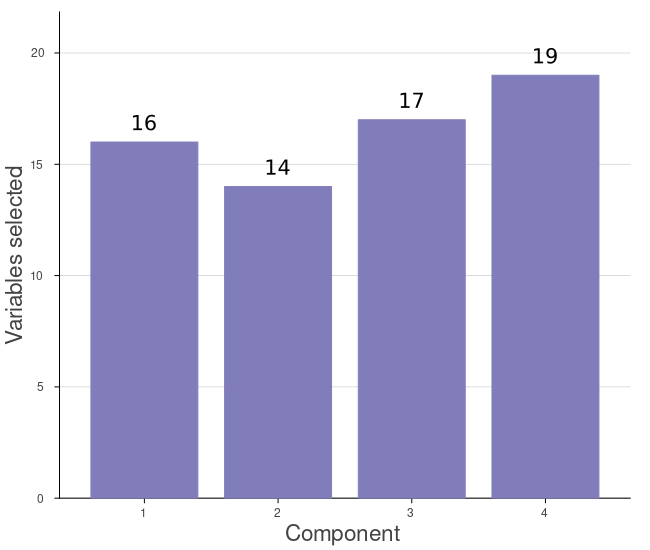

In [3]:
plot_sparsity(m.loadings)

---

# Modifying the plot

There are two ways to choose components and they differ in an important way. `ncomp` takes a **leading count** — `ncomp = 2` gives components 1 and 2 — while `comps` takes an explicit vector, so a non-contiguous set like `[1, 3]` is possible with `comps` and not with `ncomp`.

`asfraction` changes the quantity from a count to a proportion, `compnames` names the bars, `labelcounts` removes the numbers, and `sparsitycolor` sets the fill.

## Naming, and choosing components

`compnames` is subset along with the counts, so the labels stay correct whatever we select — which means we pass one name per component of the matrix, not one per entry of `comps`. That is the same convention as `varnames` on the loadings plot.

Here we take a non-contiguous pair, which only `comps` can do.

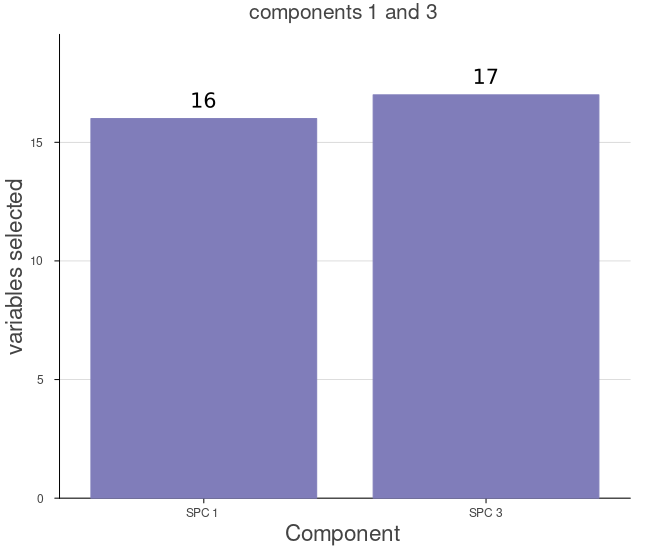

In [4]:
plot_sparsity(m.loadings;
              comps     = [1, 3],
              compnames = ["SPC $(j)" for j in 1:4],
              ylabel    = "variables selected",
              title     = "components 1 and 3")

## As a fraction

`asfraction = true` divides by the total number of variables, which reads more easily when there are many — a bar at 0.15 tells us the penalty kept fifteen percent without our needing to remember what `p` was.

The count labels turn themselves off here, since a fraction over a bar reads worse than the axis does.

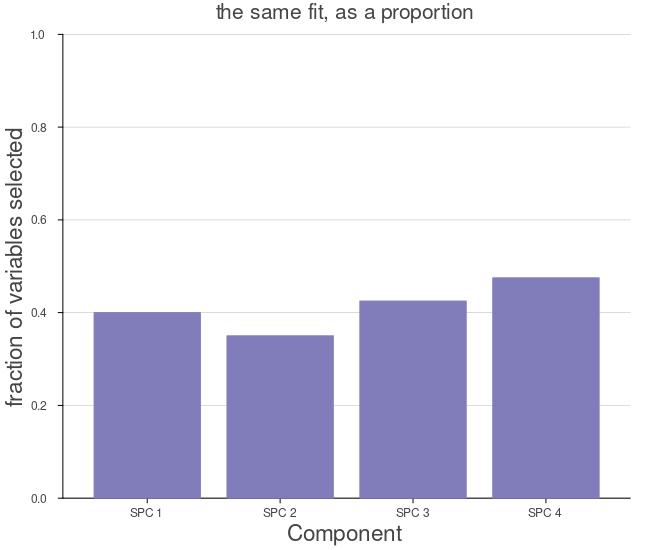

In [5]:
plot_sparsity(m.loadings;
              asfraction = true,
              compnames  = ["SPC $(j)" for j in 1:4],
              ylabel     = "fraction of variables selected",
              title      = "the same fit, as a proportion",
              ylims      = (0, 1))

## Color, and the rest

`sparsitycolor` fills the bars and `labelcounts = false` removes the numbers over them — worth doing when the figure is small enough that the labels crowd, or when it sits beside others and the axis carries the reading.

Everything else the plot sets for itself yields to what we pass.

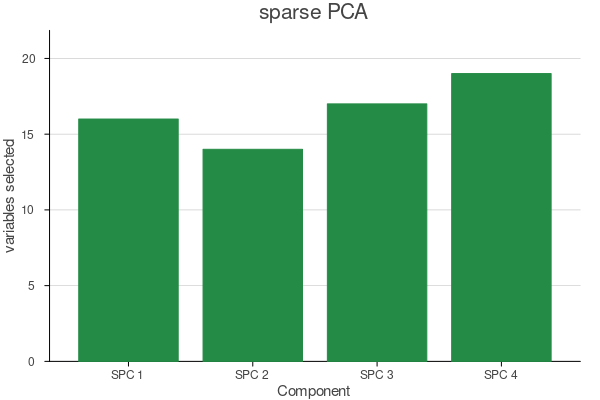

In [7]:
plot_sparsity(m.loadings;
              compnames     = ["SPC $(j)" for j in 1:4],
              sparsitycolor = "#238b45",
              labelcounts   = false,
              ylabel        = "variables selected",
              title         = "sparse PCA",
              size          = (600, 400),
              guidefontsize = 10)